In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Install & Import Library yang akan digunakan**

In [ ]:
# Install scikit-fuzzy dan pandas
!pip install scikit-fuzzy pandas

# Import library
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd

# **Import Dataset**

In [ ]:
# Membaca dataset
data = pd.read_csv('/content/drive/MyDrive/Dataset/Kecerdasan Buatan/Water Quality Testing.csv')

# **Menentukan Rentang Parameter**

In [ ]:
# Menentukan rentang parameter berdasarkan dataset (untuk validasi internal)
suhu_min, suhu_max = data['Temperature (°C)'].min(), data['Temperature (°C)'].max()  # 20.3–23.5
ph_min, ph_max = data['pH'].min(), data['pH'].max()  # 6.83–7.48
kekeruhan_min, kekeruhan_max = data['Turbidity (NTU)'].min(), data['Turbidity (NTU)'].max()  # 3.1–5.1
do_min, do_max = data['Dissolved Oxygen (mg/L)'].min(), data['Dissolved Oxygen (mg/L)'].max()  # 6.0–9.9

# **Input User**

In [ ]:
# --- Input dari pengguna tanpa menampilkan rentang ---
print("Masukkan nilai parameter untuk simulasi:")
try:
    suhu_input = float(input("Suhu air (°C): "))
    ph_input = float(input("pH air: "))
    kekeruhan_input = float(input("Kekeruhan air (NTU): "))
    do_input = float(input("Oksigen terlarut (mg/L): "))
    lama_budidaya_input = float(input("Lama budidaya ikan (hari): "))
except ValueError:
    print("Error: Masukkan angka yang valid. Menggunakan nilai default.")
    suhu_input, ph_input, kekeruhan_input, do_input, lama_budidaya_input = 22.5, 7.2, 4.5, 7.5, 120

Masukkan nilai parameter untuk simulasi:
Suhu air (°C): 27
pH air: 3
Kekeruhan air (NTU): 2
Oksigen terlarut (mg/L): 4
Lama budidaya ikan (hari): 60


# **Validasi dan Normalisasi Input Pengguna**

In [ ]:
# Validasi input dengan rentang yang lebih longgar
if suhu_input < 15 or suhu_input > 30:
    print(f"Peringatan: Suhu di luar rentang aman (15-30°C). Menggunakan nilai terdekat dalam rentang.")
    suhu_input = max(15, min(30, suhu_input))
if ph_input < 5 or ph_input > 9:
    print(f"Peringatan: pH di luar rentang aman (5-9). Menggunakan nilai terdekat dalam rentang.")
    ph_input = max(5, min(9, ph_input))
if kekeruhan_input < 2 or kekeruhan_input > 10:
    print(f"Peringatan: Kekeruhan di luar rentang aman (2-10 NTU). Menggunakan nilai terdekat dalam rentang.")
    kekeruhan_input = max(2, min(10, kekeruhan_input))
if do_input < 3 or do_input > 12:
    print(f"Peringatan: Oksigen terlarut di luar rentang aman (3-12 mg/L). Menggunakan nilai terdekat dalam rentang.")
    do_input = max(3, min(12, do_input))
if lama_budidaya_input < 0 or lama_budidaya_input > 365:
    print("Peringatan: Lama budidaya harus dalam rentang 0-365 hari. Menggunakan nilai default 120.")
    lama_budidaya_input = 120

Peringatan: pH di luar rentang aman (5-9). Menggunakan nilai terdekat dalam rentang.


# **Fuzzy Logic System untuk Kuantitas Pakan**

In [ ]:
# 1. Definisikan variabel input dan output
suhu = ctrl.Antecedent(np.arange(15, 30.1, 0.1), 'suhu')  # Suhu air (°C)
ph = ctrl.Antecedent(np.arange(5, 9.1, 0.1), 'ph')       # pH air
kuantitas_pakan = ctrl.Consequent(np.arange(0, 100, 1), 'kuantitas_pakan')  # Kuantitas pakan (gram/hari)

# 2. Definisikan fungsi keanggotaan
suhu['sangat_dingin'] = fuzz.trapmf(suhu.universe, [15, 15, 17, 18])
suhu['dingin'] = fuzz.trimf(suhu.universe, [17, 20, 22])
suhu['normal'] = fuzz.trimf(suhu.universe, [21, 22.5, 24])
suhu['panas'] = fuzz.trimf(suhu.universe, [23, 25, 27])
suhu['sangat_panas'] = fuzz.trapmf(suhu.universe, [26, 28, 30, 30])

ph['sangat_asam'] = fuzz.trapmf(ph.universe, [5, 5, 5.5, 6])
ph['asam'] = fuzz.trimf(ph.universe, [5.5, 6.5, 7])
ph['netral'] = fuzz.trimf(ph.universe, [6.8, 7.2, 7.6])
ph['basa'] = fuzz.trimf(ph.universe, [7.4, 8, 8.5])
ph['sangat_basa'] = fuzz.trapmf(ph.universe, [8, 8.5, 9, 9])

kuantitas_pakan['rendah'] = fuzz.trimf(kuantitas_pakan.universe, [0, 0, 30])
kuantitas_pakan['sedang'] = fuzz.trimf(kuantitas_pakan.universe, [20, 50, 80])
kuantitas_pakan['tinggi'] = fuzz.trimf(kuantitas_pakan.universe, [70, 100, 100])

# 3. Aturan fuzzy untuk kuantitas pakan
rules_pakan = [
    ctrl.Rule(suhu['sangat_dingin'] | ph['sangat_asam'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['dingin'] & ph['asam'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['normal'] & ph['netral'], kuantitas_pakan['sedang']),
    ctrl.Rule(suhu['panas'] & ph['netral'], kuantitas_pakan['tinggi']),
    ctrl.Rule(suhu['dingin'] & ph['basa'], kuantitas_pakan['sedang']),
    ctrl.Rule(suhu['panas'] & ph['asam'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['sangat_panas'] | ph['sangat_basa'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['normal'] & ph['basa'], kuantitas_pakan['sedang']),
    ctrl.Rule(suhu['panas'] & ph['sangat_basa'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['sangat_dingin'] & ph['netral'], kuantitas_pakan['rendah']),
    ctrl.Rule(suhu['normal'] & ph['asam'], kuantitas_pakan['sedang'])
]

# 4. Sistem kontrol fuzzy untuk kuantitas pakan
pakan_ctrl = ctrl.ControlSystem(rules_pakan)
pakan_sim = ctrl.ControlSystemSimulation(pakan_ctrl)

# 5. Input nilai dari pengguna untuk simulasi kuantitas pakan
pakan_sim.input['suhu'] = suhu_input
pakan_sim.input['ph'] = ph_input
pakan_sim.compute()
print(f"\nKuantitas pakan yang direkomendasikan: {pakan_sim.output['kuantitas_pakan']:.2f} gram/hari")


Kuantitas pakan yang direkomendasikan: 10.00 gram/hari


# **Visualisasi Rekomendasi Kuantitas Pakan Ikan**

<Figure size 800x500 with 0 Axes>

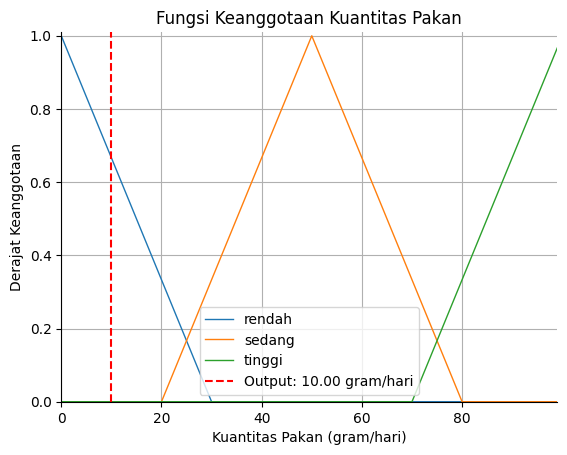

In [ ]:
# Visualisasi hasil kuantitas pakan
plt.figure(figsize=(8, 5))
kuantitas_pakan.view()
plt.axvline(x=pakan_sim.output['kuantitas_pakan'], color='r', linestyle='--', label=f'Output: {pakan_sim.output["kuantitas_pakan"]:.2f} gram/hari')
plt.title('Fungsi Keanggotaan Kuantitas Pakan')
plt.xlabel('Kuantitas Pakan (gram/hari)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True)
plt.show()

# **Fuzzy Logic System untuk Waktu Kuras Kolam**

In [ ]:
# 1. Definisikan variabel input dan output
suhu_kuras = ctrl.Antecedent(np.arange(15, 30.1, 0.1), 'suhu_kuras')
kekeruhan = ctrl.Antecedent(np.arange(2, 10.1, 0.1), 'kekeruhan')
do = ctrl.Antecedent(np.arange(3, 12.1, 0.1), 'do')
waktu_kuras = ctrl.Consequent(np.arange(0, 15, 1), 'waktu_kuras')

# 2. Definisikan fungsi keanggotaan
suhu_kuras['sangat_dingin'] = fuzz.trapmf(suhu_kuras.universe, [15, 15, 17, 18])
suhu_kuras['dingin'] = fuzz.trimf(suhu_kuras.universe, [17, 20, 22])
suhu_kuras['normal'] = fuzz.trimf(suhu_kuras.universe, [21, 22.5, 24])
suhu_kuras['panas'] = fuzz.trimf(suhu_kuras.universe, [23, 25, 27])
suhu_kuras['sangat_panas'] = fuzz.trapmf(suhu_kuras.universe, [26, 28, 30, 30])

kekeruhan['sangat_rendah'] = fuzz.trapmf(kekeruhan.universe, [2, 2, 2.5, 3])
kekeruhan['rendah'] = fuzz.trimf(kekeruhan.universe, [2.5, 3, 4])
kekeruhan['sedang'] = fuzz.trimf(kekeruhan.universe, [3.5, 4.5, 5.5])
kekeruhan['tinggi'] = fuzz.trimf(kekeruhan.universe, [5, 6, 7])
kekeruhan['sangat_tinggi'] = fuzz.trapmf(kekeruhan.universe, [6.5, 8, 10, 10])

do['sangat_rendah'] = fuzz.trapmf(do.universe, [3, 3, 4, 5])
do['rendah'] = fuzz.trimf(do.universe, [4, 5, 6.5])
do['normal'] = fuzz.trimf(do.universe, [6, 7.5, 9])
do['tinggi'] = fuzz.trimf(do.universe, [8, 10, 11])
do['sangat_tinggi'] = fuzz.trapmf(do.universe, [10, 11, 12, 12])

waktu_kuras['cepat'] = fuzz.trimf(waktu_kuras.universe, [0, 0, 5])
waktu_kuras['normal'] = fuzz.trimf(waktu_kuras.universe, [3, 7, 10])
waktu_kuras['lambat'] = fuzz.trimf(waktu_kuras.universe, [8, 15, 15])

# 3. Aturan fuzzy untuk waktu kuras
rules_kuras = [
    ctrl.Rule(suhu_kuras['panas'] & kekeruhan['tinggi'] & do['rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['normal'] & kekeruhan['sedang'] & do['normal'], waktu_kuras['normal']),
    ctrl.Rule(suhu_kuras['dingin'] & kekeruhan['rendah'] & do['tinggi'], waktu_kuras['lambat']),
    ctrl.Rule(suhu_kuras['panas'] & kekeruhan['rendah'] & do['normal'], waktu_kuras['normal']),
    ctrl.Rule(suhu_kuras['dingin'] & kekeruhan['tinggi'] & do['rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['normal'] & kekeruhan['rendah'] & do['tinggi'], waktu_kuras['lambat']),
    ctrl.Rule(suhu_kuras['panas'] & kekeruhan['sedang'] & do['rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['sangat_panas'] | kekeruhan['sangat_tinggi'] | do['sangat_rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['sangat_dingin'] & kekeruhan['sangat_rendah'] & do['sangat_tinggi'], waktu_kuras['lambat']),
    ctrl.Rule(suhu_kuras['normal'] & kekeruhan['tinggi'] & do['rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['dingin'] & kekeruhan['sedang'] & do['normal'], waktu_kuras['normal']),
    ctrl.Rule(suhu_kuras['panas'] & kekeruhan['sangat_rendah'] & do['tinggi'], waktu_kuras['normal']),
    ctrl.Rule(suhu_kuras['sangat_dingin'] | kekeruhan['sangat_tinggi'] | do['rendah'], waktu_kuras['cepat']),
    ctrl.Rule(suhu_kuras['normal'] & kekeruhan['sangat_rendah'] & do['sangat_tinggi'], waktu_kuras['lambat']),
    ctrl.Rule(suhu_kuras['dingin'] & kekeruhan['sedang'] & do['tinggi'], waktu_kuras['normal']),
    ctrl.Rule(suhu_kuras['panas'] & kekeruhan['tinggi'] & do['normal'], waktu_kuras['cepat'])
]

# 4. Sistem kontrol fuzzy untuk waktu kuras
kuras_ctrl = ctrl.ControlSystem(rules_kuras)
kuras_sim = ctrl.ControlSystemSimulation(kuras_ctrl)

# 5. Input nilai dari pengguna untuk simulasi waktu kuras
kuras_sim.input['suhu_kuras'] = suhu_input
kuras_sim.input['kekeruhan'] = kekeruhan_input
kuras_sim.input['do'] = do_input
kuras_sim.compute()

# 6. Hitung output dan tambahkan warning serta pemberitahuan
waktu_kuras_hari = kuras_sim.output['waktu_kuras']
print(f"\nWaktu kuras kolam yang direkomendasikan: {waktu_kuras_hari:.2f} hari")

# Warning dan pemberitahuan untuk waktu kuras
if waktu_kuras_hari <= 2:
    print("WARNING: Kuras kolam segera! Kondisi air buruk (suhu tinggi, kekeruhan tinggi, atau oksigen rendah).")
    print("Pemberitahuan: Sudah waktunya membersihkan kolam sekarang!")
elif waktu_kuras_hari <= 5:
    print("Peringatan: Kuras kolam dalam waktu dekat untuk menjaga kualitas air.")
    print("Pemberitahuan: Siapkan pembersihan kolam dalam beberapa hari ke depan.")
else:
    print("Kondisi air masih baik, kuras sesuai jadwal normal.")


Waktu kuras kolam yang direkomendasikan: 1.67 hari
Pemberitahuan: Sudah waktunya membersihkan kolam sekarang!


# **Visualisasi Rekomendasi Waktu Kuras Kolam**

<Figure size 800x500 with 0 Axes>

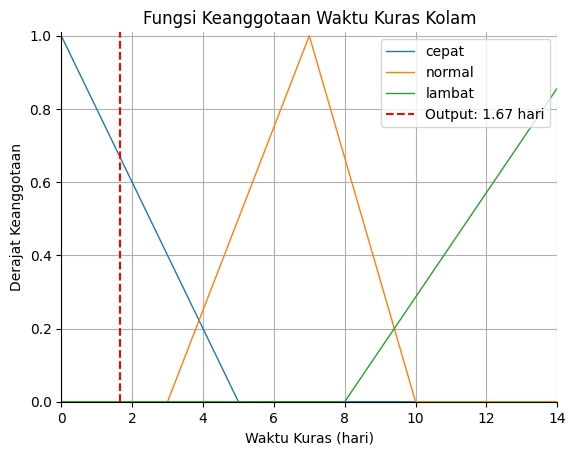

In [ ]:
# Visualisasi hasil waktu kuras
plt.figure(figsize=(8, 5))
waktu_kuras.view()
plt.axvline(x=waktu_kuras_hari, color='r', linestyle='--', label=f'Output: {waktu_kuras_hari:.2f} hari')
plt.title('Fungsi Keanggotaan Waktu Kuras Kolam')
plt.xlabel('Waktu Kuras (hari)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True)
plt.show()

# **Fuzzy Logic System untuk Waktu Panen**

In [ ]:
# --- Sistem Fuzzy untuk Waktu Panen ---
# 1. Definisikan variabel input dan output
lama_budidaya = ctrl.Antecedent(np.arange(0, 365, 1), 'lama_budidaya')  # Lama budidaya (hari)
waktu_panen = ctrl.Consequent(np.arange(60, 240, 1), 'waktu_panen')     # Waktu panen (hari)

# 2. Definisikan fungsi keanggotaan
lama_budidaya['pendek'] = fuzz.trapmf(lama_budidaya.universe, [0, 0, 60, 90])
lama_budidaya['sedang'] = fuzz.trimf(lama_budidaya.universe, [60, 120, 180])
lama_budidaya['panjang'] = fuzz.trapmf(lama_budidaya.universe, [150, 180, 365, 365])

waktu_panen['cepat'] = fuzz.trimf(waktu_panen.universe, [60, 90, 120])
waktu_panen['normal'] = fuzz.trimf(waktu_panen.universe, [90, 150, 180])
waktu_panen['lambat'] = fuzz.trimf(waktu_panen.universe, [150, 210, 240])

# 3. Aturan fuzzy untuk waktu panen
rules_panen = [
    ctrl.Rule(lama_budidaya['pendek'], waktu_panen['cepat']),
    ctrl.Rule(lama_budidaya['sedang'], waktu_panen['normal']),
    ctrl.Rule(lama_budidaya['panjang'], waktu_panen['lambat'])
]

# 4. Sistem kontrol fuzzy untuk waktu panen
panen_ctrl = ctrl.ControlSystem(rules_panen)
panen_sim = ctrl.ControlSystemSimulation(panen_ctrl)

# 5. Input nilai dari pengguna untuk simulasi waktu panen
panen_sim.input['lama_budidaya'] = lama_budidaya_input
panen_sim.compute()
waktu_panen = panen_sim.output['waktu_panen']
print(f"\nWaktu panen yang direkomendasikan untuk lama budidaya {lama_budidaya_input} hari: {waktu_panen:.2f} hari")

# Warning untuk waktu panen
if lama_budidaya_input >= waktu_panen:
    print(f"WARNING: Ikan sudah melewati waktu panen optimal ({waktu_panen:.2f} hari)! Panen segera.")
elif lama_budidaya_input >= waktu_panen - 10:
    print(f"Peringatan: Ikan mendekati waktu panen optimal ({waktu_panen:.2f} hari). Siapkan panen.")
else:
    print(f"Ikan belum mencapai waktu panen optimal. Waktu panen diperkirakan pada {waktu_panen:.2f} hari.")


Waktu panen yang direkomendasikan untuk lama budidaya 60.0 hari: 90.00 hari
Ikan belum mencapai waktu panen optimal. Waktu panen diperkirakan pada 90.00 hari.


# **Visualisasi Rekomendasi Waktu Panen**

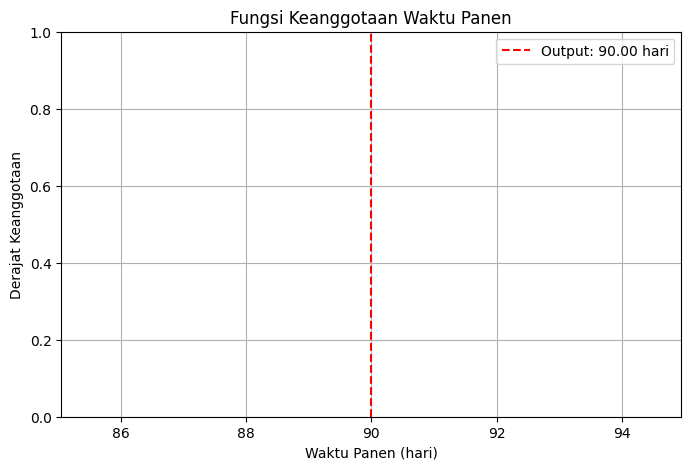

In [ ]:
# Visualisasi hasil waktu panen
plt.figure(figsize=(8, 5))
waktu_panen.view()
plt.axvline(x=waktu_panen, color='r', linestyle='--', label=f'Output: {waktu_panen:.2f} hari')
plt.title('Fungsi Keanggotaan Waktu Panen')
plt.xlabel('Waktu Panen (hari)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True)
plt.show()